# Exploratory Data Analysis (EDA)
## Amazon Best Sellers & User Rating (2009-2019)

Notebook ini melakukan eksplorasi terhadap dataset Amazon Top 50 Bestselling Books (2009-2019) untuk memahami:
- Struktur dan kualitas data (duplikasi, missing value)
- Distribusi `User Rating`, `Price`, dan `Genre`
- Hubungan antar variabel numerik (korelasi)
- Tren rating dari tahun ke tahun

Hasil EDA ini menjadi dasar pemilihan fitur untuk clustering K-Means pada notebook `02_kmeans_clustering.ipynb`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

## 1. Load & Inspeksi Data

In [2]:
df = pd.read_csv('../data/raw/bestsellers.csv')
print('Shape:', df.shape)
df.head()

Shape: (550, 7)


,Name,Author,User Rating,Reviews,Price,Year,Genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 550 entries, 0 to 549
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Name         550 non-null    str    
 1   Author       550 non-null    str    
 2   User Rating  550 non-null    float64
 3   Reviews      550 non-null    int64  
 4   Price        550 non-null    int64  
 5   Year         550 non-null    int64  
 6   Genre        550 non-null    str    
dtypes: float64(1), int64(3), str(3)
memory usage: 30.2 KB


In [4]:
# Cek kualitas data: missing value & duplikasi
print('Missing values per kolom:')
print(df.isnull().sum())
print()
print('Baris duplikat (semua kolom sama):', df.duplicated().sum())
print('Jumlah judul buku unik (kolom Name):', df['Name'].nunique(), 'dari', len(df), 'baris')

Missing values per kolom:
Name           0
Author         0
User Rating    0
Reviews        0
Price          0
Year           0
Genre          0
dtype: int64

Baris duplikat (semua kolom sama): 0
Jumlah judul buku unik (kolom Name): 351 dari 550 baris


**Catatan:** Tidak ada missing value maupun baris duplikat persis. Namun jumlah judul unik (351) lebih sedikit dari total baris (550) — artinya banyak buku muncul sebagai bestseller di lebih dari satu tahun. Unit analisis di dataset ini adalah *"kemunculan sebagai bestseller per tahun"*, bukan buku unik.

In [5]:
df.describe()

,User Rating,Reviews,Price,Year
count,550.000000,550.000000,550.000000,550.000000
mean,4.618364,11953.281818,13.100000,2014.000000
std,0.226980,11731.132017,10.842262,3.165156
min,3.300000,37.000000,0.000000,2009.000000
25%,4.500000,4058.000000,7.000000,2011.000000
50%,4.700000,8580.000000,11.000000,2014.000000
75%,4.800000,17253.250000,16.000000,2017.000000
max,4.900000,87841.000000,105.000000,2019.000000


## 2. Distribusi Variabel Numerik

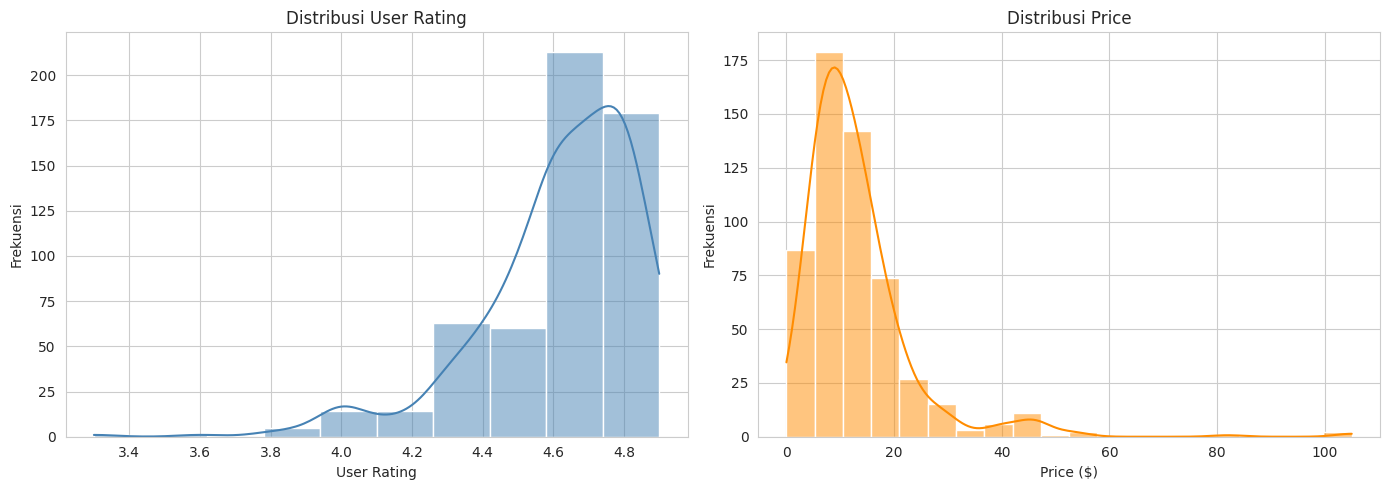

Rating < 4.0: 7 buku (1.3%)
Buku gratis (Price = 0): 12 buku
Buku Price > 40 (outlier mahal): 17 buku


In [6]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df, x='User Rating', bins=10, kde=True, ax=ax[0], color='steelblue')
ax[0].set_title('Distribusi User Rating')
ax[0].set_xlabel('User Rating')
ax[0].set_ylabel('Frekuensi')

sns.histplot(data=df, x='Price', bins=20, kde=True, ax=ax[1], color='darkorange')
ax[1].set_title('Distribusi Price')
ax[1].set_xlabel('Price ($)')
ax[1].set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()

print(f"Rating < 4.0: {(df['User Rating'] < 4.0).sum()} buku ({(df['User Rating'] < 4.0).mean()*100:.1f}%)")
print(f"Buku gratis (Price = 0): {(df['Price'] == 0).sum()} buku")
print(f"Buku Price > 40 (outlier mahal): {(df['Price'] > 40).sum()} buku")

**Insight:**
- `User Rating` **left-skewed** dan terkonsentrasi tinggi (median 4.7). Wajar karena ini daftar *bestseller* — buku dengan rating rendah jarang bertahan lama di daftar.
- `Price` **right-skewed**, mayoritas $0-20, dengan sedikit outlier hingga >$100 (kemungkinan box set / buku referensi).

## 3. Distribusi Genre

Genre
Non Fiction    310
Fiction        240
Name: count, dtype: int64


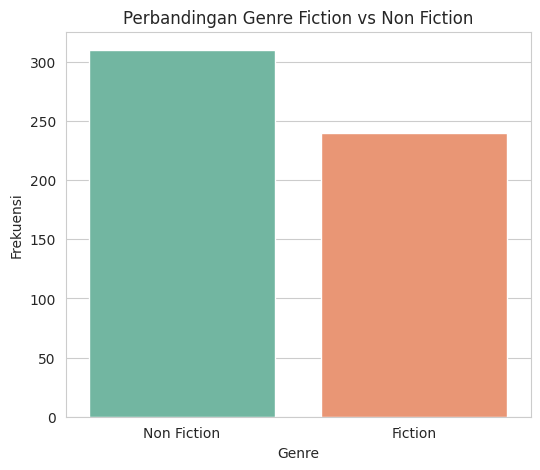

In [7]:
genre_counts = df['Genre'].value_counts()
print(genre_counts)

plt.figure(figsize=(6, 5))
sns.countplot(data=df, x='Genre', hue='Genre', palette='Set2', legend=False)
plt.title('Perbandingan Genre Fiction vs Non Fiction')
plt.xlabel('Genre')
plt.ylabel('Frekuensi')
plt.show()

In [8]:
df.groupby('Genre')[['User Rating', 'Price', 'Reviews']].mean().round(2)

,User Rating,Price,Reviews
Genre,,,
Fiction,4.65,10.85,15683.79
Non Fiction,4.60,14.84,9065.15


**Insight:** Non Fiction sedikit lebih banyak (310 vs 240), tapi Fiction punya rata-rata `Reviews` jauh lebih tinggi (~15.7k vs ~9.1k) dan rating sedikit lebih tinggi. Non Fiction rata-rata lebih mahal.

## 4. Korelasi Antar Variabel Numerik

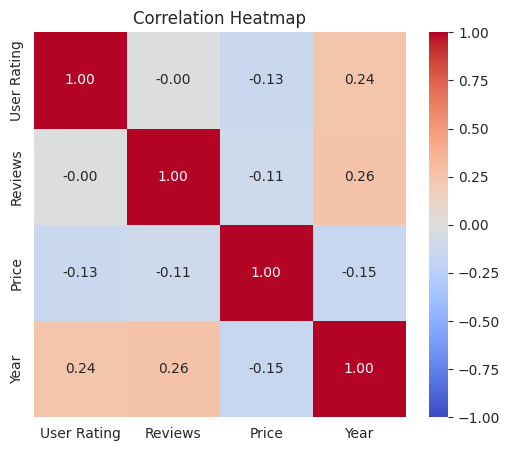

,User Rating,Reviews,Price,Year
User Rating,1.000000,-0.001729,-0.133086,0.242383
Reviews,-0.001729,1.000000,-0.109182,0.263560
Price,-0.133086,-0.109182,1.000000,-0.153979
Year,0.242383,0.263560,-0.153979,1.000000


In [9]:
corr = df[['User Rating', 'Reviews', 'Price', 'Year']].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.show()

corr

**Insight:**
- `Reviews` vs `User Rating`: hampir tidak berkorelasi (r ≈ 0.00) — jumlah review tinggi **tidak** menjamin rating tinggi.
- `Price` vs `User Rating`: korelasi lemah negatif (r ≈ -0.13) — efek kecil, bukan hubungan kuat.
- `Year` vs `Reviews`/`Rating`: korelasi positif lemah (r ≈ 0.24-0.26) — ada tren naik ringan dari 2009 ke 2019.

## 5. Hubungan Reviews & Price terhadap Rating

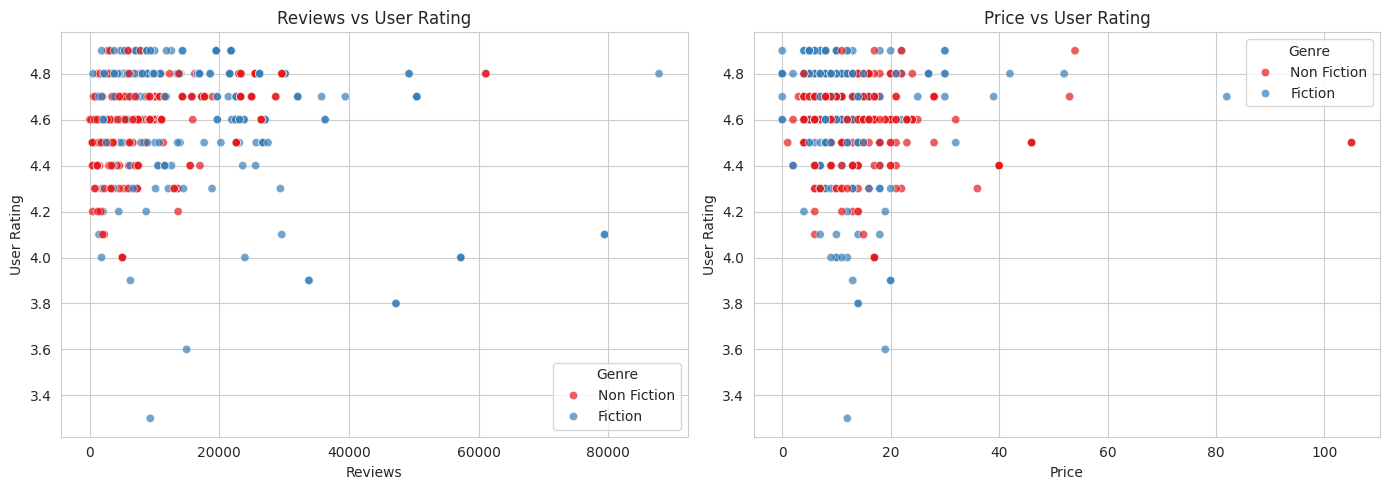

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df, x='Reviews', y='User Rating', hue='Genre', palette='Set1', ax=ax[0], alpha=0.7)
ax[0].set_title('Reviews vs User Rating')

sns.scatterplot(data=df, x='Price', y='User Rating', hue='Genre', palette='Set1', ax=ax[1], alpha=0.7)
ax[1].set_title('Price vs User Rating')

plt.tight_layout()
plt.show()

## 6. Perbandingan Price antar Genre (Boxplot)

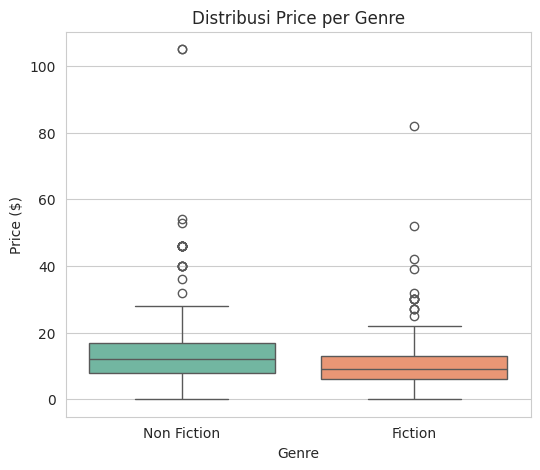

In [11]:
plt.figure(figsize=(6, 5))
sns.boxplot(data=df, x='Genre', y='Price', hue='Genre', palette='Set2', legend=False)
plt.title('Distribusi Price per Genre')
plt.ylabel('Price ($)')
plt.show()

## 7. Tren User Rating per Tahun

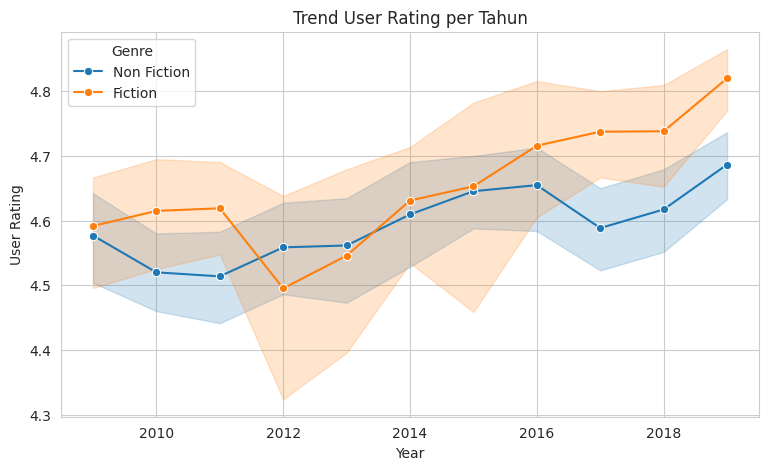

In [12]:
plt.figure(figsize=(9, 5))
sns.lineplot(data=df, x='Year', y='User Rating', hue='Genre', marker='o')
plt.title('Trend User Rating per Tahun')
plt.xlabel('Year')
plt.ylabel('User Rating')
plt.show()

## 8. Penulis dengan Kemunculan Terbanyak

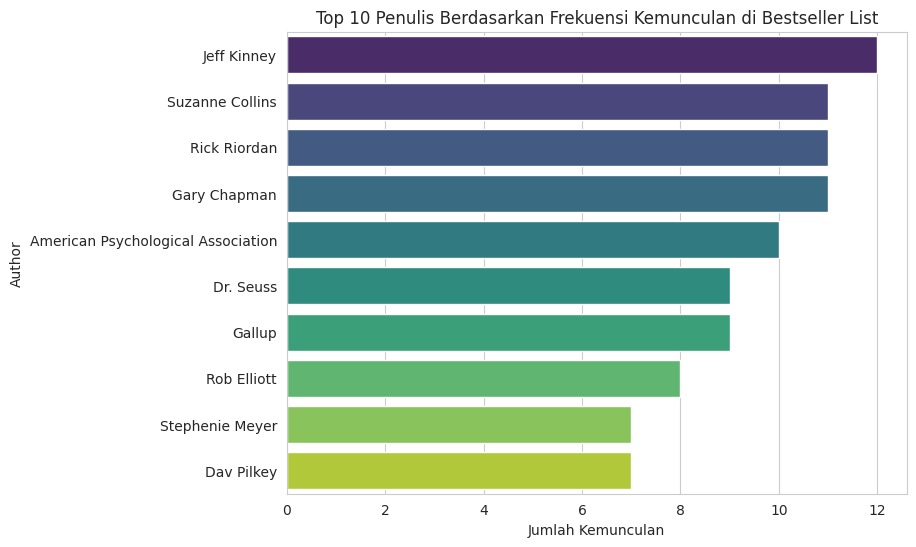

In [13]:
top_authors = df['Author'].value_counts().head(10)

plt.figure(figsize=(8, 6))
sns.barplot(x=top_authors.values, y=top_authors.index, hue=top_authors.index, palette='viridis', legend=False)
plt.title('Top 10 Penulis Berdasarkan Frekuensi Kemunculan di Bestseller List')
plt.xlabel('Jumlah Kemunculan')
plt.ylabel('Author')
plt.show()

## Ringkasan Insight EDA

1. **Rating buku bestseller cenderung seragam tinggi** (median 4.7, hanya ~1.3% di bawah 4.0) — rating bukan variabel yang banyak bervariasi/membedakan antar buku di dataset ini.
2. **Reviews dan Rating hampir tidak berkorelasi** — buku dengan review sangat banyak belum tentu rating-nya paling tinggi.
3. **Price sedikit berkorelasi negatif dengan Rating**, tapi efeknya kecil.
4. **Fiction vs Non Fiction**: Fiction lebih murah & lebih banyak di-review, Non Fiction lebih mahal.
5. **Ada tren naik ringan** pada rating & jumlah review sepanjang 2009-2019.
6. Karena `Reviews` dan `Price` jauh lebih bervariasi dibanding `Rating`, kedua variabel ini (bersama `Rating`) dipakai sebagai fitur clustering pada notebook berikutnya (`02_kmeans_clustering.ipynb`).